In [126]:
import os, re, math, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [127]:
# -------------------------
# DATA PATHS
# -------------------------
PAIRS_DIR  = Path("/zpool/vladlab/data_drive/geogaze_data/pairs")

MASK_SIDE = "R"   # "L" or "R"
if MASK_SIDE == "L":
    MASKS_DIR = Path("/zpool/vladlab/data_drive/geogaze_data/left_masks")
else:
    MASKS_DIR = Path("/zpool/vladlab/data_drive/geogaze_data/right_masks")


OUTPUT_DIR = Path("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/individuation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# CORNET REPO + CHECKPOINT
# -------------------------
CORN_NET_REPO = Path("/zpool/vladlab/active_drive/omaltz/git_repos/CORnet")  # your local clone

CKPT_PATH = Path("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_scripts/cornet_z_individuation_big_200/20260116_150138/best.pt")

# -------------------------
# TRAINING CONFIG
# -------------------------
PAIR_MIDS = ["gs_bs"]     # list, e.g. ["bc_gc", "bc_bs"]
IMG_SIZE = 224
MODEL_TAG = f"cornetIDIV_mask{MASK_SIDE}_{'-'.join(PAIR_MIDS)}"
RUN_DIR = OUTPUT_DIR / MODEL_TAG
RUN_DIR.mkdir(parents=True, exist_ok=True)



SEED = 1
EPOCHS = 200
BATCH_SIZE = 32
NUM_WORKERS = 8

VAL_SPLIT = 0.2
LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
STEP_SIZE = 10

THRESHOLD = 0.2
POS_WEIGHT = 10   

USE_AMP = (DEVICE.type == "cuda")

print("MASK_SIDE:", MASK_SIDE)
print("PAIR_MIDS:", PAIR_MIDS)
print("CKPT_PATH:", CKPT_PATH)


MASK_SIDE: R
PAIR_MIDS: ['gs_bs']
CKPT_PATH: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_scripts/cornet_z_individuation_big_200/20260116_150138/best.pt


In [128]:
def set_seed(s):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

set_seed(SEED)


In [129]:
allowed_mids = [m.strip() for m in PAIR_MIDS if m.strip()]
mid_union = "|".join(re.escape(m) for m in allowed_mids)
PAIR_RE = re.compile(rf"^pair_({mid_union})_(\d+)\.png$")

def mask_path(side, mid, id_):
    p = MASKS_DIR / f"mask{side}_{mid}_{id_}.png"
    return p if p.is_file() else None

def collect_items(side):
    items, skipped = [], 0
    for fn in os.listdir(PAIRS_DIR):
        m = PAIR_RE.match(fn)
        if not m:
            continue
        mid, id_ = m.group(1), m.group(2)
        img_p = PAIRS_DIR / fn
        msk_p = mask_path(side, mid, id_)
        if msk_p is None:
            skipped += 1
            continue
        items.append((img_p, msk_p, mid, id_))
    items.sort(key=lambda x: (x[2], int(x[3])))
    if skipped:
        print(f"[WARN] Skipped {skipped} image(s) with no matching mask{side}.")
    print(f"[INFO] Found {len(items)} (image, mask{side}) pairs across MIDs: {allowed_mids}")
    return items

all_items = collect_items(MASK_SIDE)
assert len(all_items) > 0, "No (image, mask) pairs found."
print("Example item:", all_items[0])


[INFO] Found 500 (image, maskR) pairs across MIDs: ['gs_bs']
Example item: (PosixPath('/zpool/vladlab/data_drive/geogaze_data/pairs/pair_gs_bs_0012.png'), PosixPath('/zpool/vladlab/data_drive/geogaze_data/right_masks/maskR_gs_bs_0012.png'), 'gs_bs', '0012')


In [130]:
# ImageNet normalization (matches typical CORnet training; your training notebook used this)
train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

val_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

def load_mask_binary(path: Path):
    """
    Returns mask as float tensor shape (1,H,W) with values in {0,1}.

    IMPORTANT:
    This version matches your earlier segmentation script:
      foreground = 1 where pixel == 0 (black)
    If your masks have foreground in white (255), switch to: (m > 0)
    """
    m = np.asarray(Image.open(path).convert("L"), dtype=np.uint8)
    m = (m == 0).astype(np.float32)   # <-- flip if your mask encoding differs
    return torch.from_numpy(m).unsqueeze(0)

class PairMaskDataset(Dataset):
    def __init__(self, items, tfms):
        self.items = items
        self.tfms = tfms

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        img_p, msk_p, mid, id_ = self.items[i]
        img = Image.open(img_p).convert("RGB")
        x = self.tfms(img)  # (3,224,224)
        y = load_mask_binary(msk_p)  # (1,224,224)
        return x, y, f"{mid}_{id_}"

# Split train/val
rng = random.Random(SEED)
shuf = all_items[:]
rng.shuffle(shuf)
n_val = max(1, int(len(shuf) * VAL_SPLIT))
val_items = shuf[:n_val]
trn_items = shuf[n_val:]

print(f"[INFO] Train: {len(trn_items)} | Val: {len(val_items)}")

trainloader = DataLoader(PairMaskDataset(trn_items, train_tfms),
                         batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=True)

valloader = DataLoader(PairMaskDataset(val_items, val_tfms),
                       batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)

# Sanity check batch
xb, yb, ids = next(iter(trainloader))
print("x:", xb.shape, xb.dtype)
print("y:", yb.shape, yb.dtype, "unique:", torch.unique(yb))
print("ids[0]:", ids[0])


[INFO] Train: 400 | Val: 100
x: torch.Size([32, 3, 224, 224]) torch.float32
y: torch.Size([32, 1, 224, 224]) torch.float32 unique: tensor([0., 1.])
ids[0]: gs_bs_0420


In [131]:
import sys
sys.path.insert(0, str(CORN_NET_REPO))

import cornet
print("Imported cornet from:", cornet.__file__)


Imported cornet from: /zpool/vladlab/active_drive/omaltz/git_repos/CORnet/cornet/__init__.py


In [132]:
def replace_last_linear(model: nn.Module, out_features: int):
    last_name, last_linear = None, None
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            last_name, last_linear = name, module
    if last_linear is None:
        raise RuntimeError("No nn.Linear found in model.")

    parent = model
    parts = last_name.split(".")
    for p in parts[:-1]:
        parent = getattr(parent, p)

    setattr(parent, parts[-1], nn.Linear(last_linear.in_features, out_features))
    return model, last_linear.in_features, last_name

# Build CORnet-Z (no pretrained)
corn = cornet.cornet_z(pretrained=False)

# Match your training notebook: last linear -> 5 outputs
corn, in_features, last_name = replace_last_linear(corn, out_features=5)
print(f"Replaced {last_name} with Linear({in_features} -> 5)")

corn = corn.to(DEVICE)

# Load checkpoint
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)

if isinstance(ckpt, dict) and "model_state" in ckpt:
    state = ckpt["model_state"]
elif isinstance(ckpt, dict) and "state_dict" in ckpt:
    state = ckpt["state_dict"]
else:
    state = ckpt

missing, unexpected = corn.load_state_dict(state, strict=False)
print("Loaded ckpt:", CKPT_PATH)
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))

corn.eval()


Replaced module.decoder.linear with Linear(512 -> 5)
Loaded ckpt: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_scripts/cornet_z_individuation_big_200/20260116_150138/best.pt
Missing keys: 0
Unexpected keys: 0


DataParallel(
  (module): Sequential(
    (V1): CORblock_Z(
      (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
      (nonlin): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (output): Identity()
    )
    (V2): CORblock_Z(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlin): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (output): Identity()
    )
    (V4): CORblock_Z(
      (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlin): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (output): Identity()
    )
    (IT): CORblock_Z(
      (conv): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlin): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, strid

In [133]:
print(corn)

DataParallel(
  (module): Sequential(
    (V1): CORblock_Z(
      (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
      (nonlin): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (output): Identity()
    )
    (V2): CORblock_Z(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlin): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (output): Identity()
    )
    (V4): CORblock_Z(
      (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlin): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (output): Identity()
    )
    (IT): CORblock_Z(
      (conv): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlin): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, strid

In [134]:
# Unwrap DataParallel (get the real CORnet model)
base = corn.module if isinstance(corn, nn.DataParallel) else corn
base = base.to(DEVICE)

In [135]:
# ------------------------------------------------------------
# 2) Remove the classifier by deleting the last child
#    This drops: global avg pool + flatten + linear classifier
#    What remains is the CORnet visual encoder (V1 → V2 → V4 → IT)
# ------------------------------------------------------------
children = list(base.children())
encoder = nn.Sequential(*children[:-1]).to(DEVICE)
encoder.eval()


Sequential(
  (0): CORblock_Z(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (nonlin): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (output): Identity()
  )
  (1): CORblock_Z(
    (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (nonlin): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (output): Identity()
  )
  (2): CORblock_Z(
    (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (nonlin): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (output): Identity()
  )
  (3): CORblock_Z(
    (conv): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (nonlin): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (output): Identity()
  )


In [136]:
print("Removed last child:")
print(children[-1])

Removed last child:
Sequential(
  (avgpool): AdaptiveAvgPool2d(output_size=1)
  (flatten): Flatten()
  (linear): Linear(in_features=512, out_features=5, bias=True)
  (output): Identity()
)


In [137]:
#Tiny mask head
#    - 1x1 conv: C feature channels → 1 mask channel
#    - Upsample to 224 x 224
class TinyMaskHead(nn.Module):
    def __init__(self, in_ch: int):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, 1, kernel_size=1)

    def forward(self, feats: torch.Tensor) -> torch.Tensor:
        logits = self.proj(feats)  # [B, 1, H', W']
        logits = F.interpolate(
            logits,
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        )
        return logits

In [138]:
# 4) Infer how many channels CORnet outputs (should be 512 for IT feautre map)

with torch.no_grad():
    dummy = torch.zeros(1, 3, 224, 224, device=DEVICE)
    feats = encoder(dummy)
    in_ch = feats.shape[1]

print("Encoder feature shape:", feats.shape)

head = TinyMaskHead(in_ch).to(DEVICE)

Encoder feature shape: torch.Size([1, 512, 7, 7])


In [139]:
# 5) Combine encoder + head into one model

class CORnetMaskModel(nn.Module):
    def __init__(self, encoder: nn.Module, head: nn.Module):
        super().__init__()
        self.encoder = encoder
        self.head = head

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = self.encoder(x)      # [B, C, H', W']
        logits = self.head(feats)    # [B, 1, 224, 224]
        return logits

model = CORnetMaskModel(encoder, head).to(DEVICE)

In [140]:
# 6) Freeze encoder, train only the head
for p in model.encoder.parameters():
    p.requires_grad = False

for p in model.head.parameters():
    p.requires_grad = True

In [141]:
# Report parameter counts FOR SANITY 
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 513 / 1,559,169


In [142]:
#forward pass shape for sanity 
with torch.no_grad():
    x = torch.zeros(2, 3, 224, 224, device=DEVICE)
    y = model(x)
    print("Output mask logits shape:", y.shape)

Output mask logits shape: torch.Size([2, 1, 224, 224])


In [143]:
# Image transform: convert RGB -> tensor and normalize (ImageNet norms are typical for CORnet-like backbones).
img_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),   # safe even if already 224x224
    T.ToTensor(),                     # [0,1], shape [3,H,W]
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

# Mask transform:
# - load as grayscale
# - convert to numpy for thresholding
# -  BLACK = object, WHITE = background
#   so we invert by using (pixel < 128) => object=1, background=0
def load_mask_as_binary_1chw(mask_path):
    m = Image.open(mask_path).convert("L")     # grayscale 0..255
    m = m.resize((IMG_SIZE, IMG_SIZE), resample=Image.NEAREST)
    m = np.array(m, dtype=np.uint8)           # [H,W], 0..255
    m = (m < 128).astype(np.float32)          # black->1, white->0
    m = torch.from_numpy(m).unsqueeze(0)      # [1,H,W]
    return m

# 2) Dataset
class PairMaskDataset(Dataset):
    """
    Returns:
      image: FloatTensor [3,224,224] (normalized)
      mask:  FloatTensor [1,224,224] (0/1, where 1 = object)
    """
    def __init__(self, items, img_transform):
        self.items = items
        self.img_transform = img_transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, mask_path, mid, id_ = self.items[idx]

        # Load RGB image
        img = Image.open(img_path).convert("RGB")
        img = self.img_transform(img)

        # Load + binarize mask (black = 1, white = 0)
        mask = load_mask_as_binary_1chw(mask_path)

        return img, mask

dataset = PairMaskDataset(all_items, img_tf)

# 3) Train / Val split (deterministic)
# Make a shuffled list of indices, then slice into train/val.
n = len(dataset)
idxs = list(range(n))
random.Random(SEED).shuffle(idxs)

n_val = int(round(n * VAL_SPLIT))
val_idxs = idxs[:n_val]
train_idxs = idxs[n_val:]

train_ds = Subset(dataset, train_idxs)
val_ds   = Subset(dataset, val_idxs)

print(f"Total: {n} , Train: {len(train_ds)}, Val: {len(val_ds)}")

# DataLoaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,             # shuffle each epoch
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)
print(all_items)

Total: 500 , Train: 400, Val: 100
[(PosixPath('/zpool/vladlab/data_drive/geogaze_data/pairs/pair_gs_bs_0012.png'), PosixPath('/zpool/vladlab/data_drive/geogaze_data/right_masks/maskR_gs_bs_0012.png'), 'gs_bs', '0012'), (PosixPath('/zpool/vladlab/data_drive/geogaze_data/pairs/pair_gs_bs_0024.png'), PosixPath('/zpool/vladlab/data_drive/geogaze_data/right_masks/maskR_gs_bs_0024.png'), 'gs_bs', '0024'), (PosixPath('/zpool/vladlab/data_drive/geogaze_data/pairs/pair_gs_bs_0036.png'), PosixPath('/zpool/vladlab/data_drive/geogaze_data/right_masks/maskR_gs_bs_0036.png'), 'gs_bs', '0036'), (PosixPath('/zpool/vladlab/data_drive/geogaze_data/pairs/pair_gs_bs_0048.png'), PosixPath('/zpool/vladlab/data_drive/geogaze_data/right_masks/maskR_gs_bs_0048.png'), 'gs_bs', '0048'), (PosixPath('/zpool/vladlab/data_drive/geogaze_data/pairs/pair_gs_bs_0060.png'), PosixPath('/zpool/vladlab/data_drive/geogaze_data/right_masks/maskR_gs_bs_0060.png'), 'gs_bs', '0060'), (PosixPath('/zpool/vladlab/data_drive/geogaze

In [144]:
# Model outputs LOGITS (not probabilities)
# Masks are 0/1 with shape [B, 1, 224, 224]
# BCEWithLogitsLoss applies sigmoid internally
criterion = nn.BCEWithLogitsLoss()

In [145]:
# Only train the head parameters
optimizer = torch.optim.SGD(
    model.head.parameters(),
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
)

In [146]:

# TRAINING LOOP
best_val_loss = float("inf")


for epoch in range(EPOCHS):

    # TRAINING PHASE

    model.train()           # enable training mode (head only)
    train_loss = 0.0

    for imgs, masks in train_loader:
        # Move batch to GPU/CPU
        imgs = imgs.to(DEVICE)      # [B,3,224,224]
        masks = masks.to(DEVICE)    # [B,1,224,224]

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(imgs)        # [B,1,224,224]

        # Compute loss
        loss = criterion(logits, masks)

        # Backpropagate loss
        loss.backward()

        # Update ONLY the head weights
        optimizer.step()

        # Accumulate loss for reporting
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION PHASE (no learning)
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            logits = model(imgs)
            loss = criterion(logits, masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.head.state_dict(), RUN_DIR / "mask_head_best.pt")


    # PRINT PROGRESS
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )


Epoch [1/200] | Train Loss: 0.4174 | Val Loss: 0.4556
Epoch [2/200] | Train Loss: 0.4433 | Val Loss: 0.4085
Epoch [3/200] | Train Loss: 0.3231 | Val Loss: 0.3147
Epoch [4/200] | Train Loss: 0.2228 | Val Loss: 0.1923
Epoch [5/200] | Train Loss: 0.1344 | Val Loss: 0.1160
Epoch [6/200] | Train Loss: 0.0786 | Val Loss: 0.0681
Epoch [7/200] | Train Loss: 0.0575 | Val Loss: 0.0563
Epoch [8/200] | Train Loss: 0.0529 | Val Loss: 0.0541
Epoch [9/200] | Train Loss: 0.0495 | Val Loss: 0.0521
Epoch [10/200] | Train Loss: 0.0473 | Val Loss: 0.0511
Epoch [11/200] | Train Loss: 0.0463 | Val Loss: 0.0499
Epoch [12/200] | Train Loss: 0.0458 | Val Loss: 0.0496
Epoch [13/200] | Train Loss: 0.0454 | Val Loss: 0.0492
Epoch [14/200] | Train Loss: 0.0446 | Val Loss: 0.0490
Epoch [15/200] | Train Loss: 0.0445 | Val Loss: 0.0492
Epoch [16/200] | Train Loss: 0.0444 | Val Loss: 0.0486
Epoch [17/200] | Train Loss: 0.0434 | Val Loss: 0.0488
Epoch [18/200] | Train Loss: 0.0435 | Val Loss: 0.0486
Epoch [19/200] | Tr

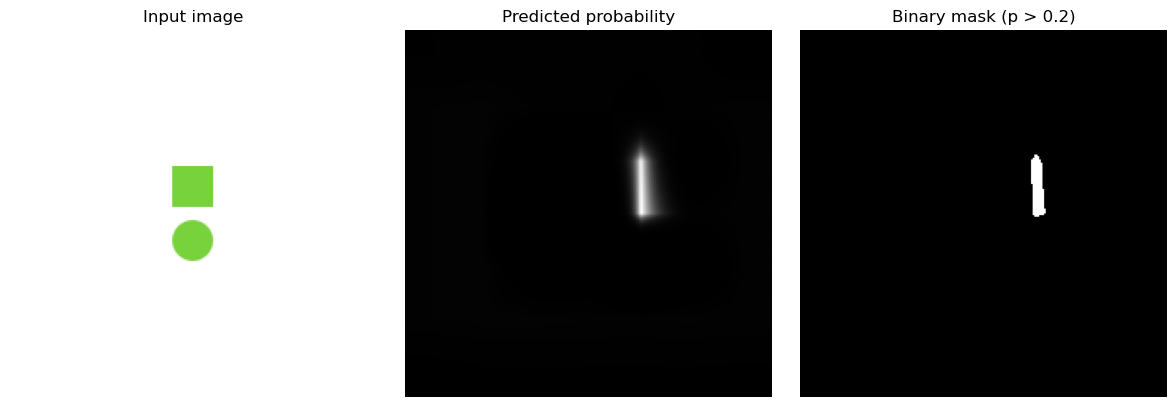

(224, 224)
          0         1         2         3         4         5         6    \
0    0.001518  0.001518  0.001518  0.001518  0.001518  0.001518  0.001518   
1    0.001518  0.001518  0.001518  0.001518  0.001518  0.001518  0.001518   
2    0.001518  0.001518  0.001518  0.001518  0.001518  0.001518  0.001518   
3    0.001518  0.001518  0.001518  0.001518  0.001518  0.001518  0.001518   
4    0.001518  0.001518  0.001518  0.001518  0.001518  0.001518  0.001518   
..        ...       ...       ...       ...       ...       ...       ...   
219  0.001005  0.001005  0.001005  0.001005  0.001005  0.001005  0.001005   
220  0.001005  0.001005  0.001005  0.001005  0.001005  0.001005  0.001005   
221  0.001005  0.001005  0.001005  0.001005  0.001005  0.001005  0.001005   
222  0.001005  0.001005  0.001005  0.001005  0.001005  0.001005  0.001005   
223  0.001005  0.001005  0.001005  0.001005  0.001005  0.001005  0.001005   

          7         8         9    ...       214       215      

In [147]:

#RUNS ONE PICTURE THROUGH CORNETZWITHMASKHEAD AND GIVES PREDICTION NPARRAY and mask for threshold(no longer using)
TEST_IMG_PATH = Path("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/decoder_model/stimuli/out/test_stimuli/test_pairs/test_gs_gc_UD.png")

# 2) Load + transform the image (use the SAME transform as training)
img_pil = Image.open(TEST_IMG_PATH).convert("RGB")
x = img_tf(img_pil).unsqueeze(0).to(DEVICE)   # [1,3,224,224]

# 3) Forward pass
model.eval()
with torch.no_grad():
    logits = model(x)                          # [1,1,224,224]
    probs  = torch.sigmoid(logits)             # [1,1,224,224] probabilities in [0,1]
    pred   = (probs > THRESHOLD).float()       # [1,1,224,224] binary mask (0/1)

# 4) Convert to numpy for plotting
#
prob_map = probs.squeeze().cpu().numpy()       # [224,224]
bin_mask = pred.squeeze().cpu().numpy()        # [224,224]

# For visualization: unnormalize the image back to 0..1
img_vis = x.squeeze(0).detach().cpu().clone()  # [3,224,224]
img_vis[0] = img_vis[0] * 0.229 + 0.485
img_vis[1] = img_vis[1] * 0.224 + 0.456
img_vis[2] = img_vis[2] * 0.225 + 0.406
img_vis = img_vis.permute(1, 2, 0).clamp(0, 1).numpy()  # [224,224,3]

# 5) Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_vis)
plt.title("Input image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(prob_map, cmap="gray")
plt.title("Predicted probability")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(bin_mask, cmap="gray")
plt.title(f"Binary mask (p > {THRESHOLD})")
plt.axis("off")

plt.tight_layout()
plt.show()

print(prob_map.shape)

df_pred= pd.DataFrame(prob_map)

print(df_pred)

df_pred.to_csv("output.csv", index=False)


In [148]:
#FINDS MEAN MASK PREDICTION GIVEN A DATAFRAME FOR ONE PICTURE
# Load black/white image -> binary mask DataFrame
# Black object (0)   -> 1
# White background   -> 0
def load_mask_df(img_path: str | Path) -> pd.DataFrame:
    img_path = Path(img_path)

    # Load image as grayscale
    img = Image.open(img_path).convert("L")

    # Enforce size
    if img.size != (224, 224):
        raise ValueError(f"{img_path} has size {img.size}, expected (224, 224)")

    arr = np.array(img, dtype=np.uint8)

    # Threshold to binary: white=1, black=0
    bw = (arr > 127).astype(np.uint8)

    # INVERT so black object becomes 1
    mask = 1 - bw

    return pd.DataFrame(mask)


# Ensure x is valid
def prepare_x(x: pd.DataFrame | np.ndarray) -> np.ndarray:
    if isinstance(x, pd.DataFrame):
        x = x.to_numpy()

    if x.shape != (224, 224):
        raise ValueError(f"x has shape {x.shape}, expected (224, 224)")

    x = x.astype(np.float32)

    if x.min() < 0 or x.max() > 1:
        raise ValueError("x must contain values between 0 and 1")

    return x


# Compute masked mean
def masked_mean(x: np.ndarray, mask: np.ndarray, name: str) -> float:
    sel = mask == 1
    n = sel.sum()

    if n == 0:
        raise ValueError(f"{name} mask contains zero object pixels")

    return float(x[sel].mean())


# Main computation
def compute_target_vs_distractor_means(
    x: pd.DataFrame | np.ndarray,
    target_img: str | Path,
    distractor_img: str | Path,
) -> dict:

    x = prepare_x(x)

    target_mask = load_mask_df(target_img).to_numpy()
    distractor_mask = load_mask_df(distractor_img).to_numpy()

    return {
        "target_mean": masked_mean(x, target_mask, "target"),
        "distractor_mean": masked_mean(x, distractor_mask, "distractor"),
        "n_target_pixels": int(target_mask.sum()),
        "n_distractor_pixels": int(distractor_mask.sum()),
    }


# Example usage
if __name__ == "__main__":

    
    x = df_pred

    target_img = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/decoder_model/stimuli/out/test_stimuli/test_acc_masks/test_down_c_mask.png"
    distractor_img = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/decoder_model/stimuli/out/test_stimuli/test_acc_masks/test_up_s_mask.png"

    results = compute_target_vs_distractor_means(
        x=x,
        target_img=target_img,
        distractor_img=distractor_img,
    )

    print(results)


{'target_mean': 1.7438953364035115e-05, 'distractor_mean': 2.7749356377171353e-05, 'n_target_pixels': 489, 'n_distractor_pixels': 625}


In [149]:
print(RUN_DIR)

/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/individuation/cornetIDIV_maskR_gs_bs


In [150]:
from pathlib import Path
import torch
import pandas as pd
from PIL import Image

TEST_IMG_DIR = Path("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/individuation/test_images")

PRED_MAP_FOLDER = TEST_IMG_DIR / MODEL_TAG

# File extensions to process
EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp")

# Assumes these already exist from your notebook:
#   model (your CORnet+maskhead model)
#   img_tf (the SAME transform as training)
#   DEVICE (e.g., "cuda" or "cpu")

# ============================
# RUN BATCH INFERENCE
# ============================
model.eval()

image_paths = [p for p in PRED_MAP_FOLDER.iterdir() if p.is_file() and p.suffix.lower() in EXTS]
print(f"Found {len(image_paths)} images in: {PRED_MAP_FOLDER}")

with torch.no_grad():
    for img_path in sorted(image_paths):
        # 1) Load image
        img_pil = Image.open(img_path).convert("RGB")

        # 2) Transform + add batch dim + move to device
        x = img_tf(img_pil).unsqueeze(0).to(DEVICE)  # [1,3,224,224]

        # 3) Forward pass
        logits = model(x)                 # [1,1,224,224]
        probs  = torch.sigmoid(logits)    # [1,1,224,224]

        # 4) Convert prob map to numpy (224x224)
        prob_map = probs.squeeze().detach().cpu().numpy()  # [224,224]

        # 5) Save as CSV named {image_name}_prob_map.csv
        out_name = f"{img_path.stem}_prob_map.csv"
        out_path = RUN_DIR / out_name

        df_prob = pd.DataFrame(prob_map)
        df_prob.to_csv(out_path, index=False)

        print(f"Saved: {out_path}")


Found 6 images in: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/individuation/test_images/cornetIDIV_maskR_gs_bs
Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/individuation/cornetIDIV_maskR_gs_bs/test_bs_bs_LR_prob_map.csv
Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/individuation/cornetIDIV_maskR_gs_bs/test_bs_gs_LR_prob_map.csv
Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/individuation/cornetIDIV_maskR_gs_bs/test_bs_gs_UD_prob_map.csv
Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/individuation/cornetIDIV_maskR_gs_bs/test_gs_bs_LR_prob_map.csv
Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/individuation/cornetIDIV_maskR_gs_bs/test_gs_bs_UD_prob_map.csv
Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/individuation/cornetIDIV_maskR_gs_bs/test_gs_gs_LR_prob_map.csv
